# A/B-тестирование новой рекомендательной системы

Проект выполнен для компании, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Необходимо провести анализ новой рекомендательной системы: рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

## Описание данных

Работа будет вестись с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


###### Задача: 
Рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

sessions_history = pd.read_csv('/datasets/sessions_project_history.csv')

sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитаем количество уникальных сессий `session_id`.

- Выведем на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберите любого из них.

- Изучим таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [13]:
session_counts = (
    sessions_history
    .groupby('user_id')['session_id']
    .nunique()
)

top_user_id = session_counts.idxmax()

sessions_history[sessions_history['user_id'] == top_user_id]

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций
Используя исторические данные, провизуализируем, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации.

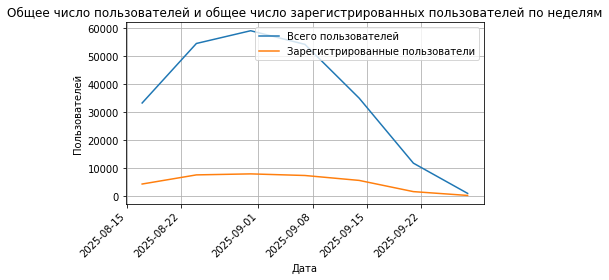

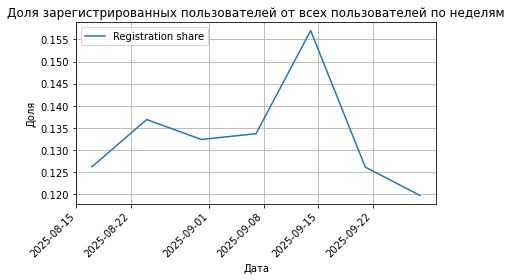

In [14]:
sessions_history = pd.read_csv('/datasets/sessions_project_history.csv')

sessions_history['session_date'] = pd.to_datetime(sessions_history['session_date'])

weekly_stats = (
    sessions_history
    .groupby(pd.Grouper(key='session_date', freq='W'))
    .agg(
        total_users=('user_id', 'nunique'),
        registered_users=('registration_flag', lambda x: x.astype(bool).sum())
    )
    .reset_index()
)

plt.figure()
plt.plot(weekly_stats['session_date'], weekly_stats['total_users'], label='Всего пользователей')
plt.plot(weekly_stats['session_date'], weekly_stats['registered_users'], label='Зарегистрированные пользователи')
plt.title('Общее число пользователей и общее число зарегистрированных пользователей по неделям')
plt.xlabel('Дата')
plt.ylabel('Пользователей')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

weekly_stats['registration_share'] = (
    weekly_stats['registered_users'] / weekly_stats['total_users']
)

plt.figure()
plt.plot(weekly_stats['session_date'], weekly_stats['registration_share'], label='Registration share')
plt.title('Доля зарегистрированных пользователей от всех пользователей по неделям')
plt.xlabel('Дата')
plt.ylabel('Доля')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Видно, что количество пользователей падает с начала сентября, а доля зарегистрированных со второй половины месяца

#### 1.4. Анализ числа просмотренных страниц

Проанализируем число просмотренных страниц во время первых сессий пользователей. Найдем количество первых сессий для каждого значения количества просмотренных страниц.

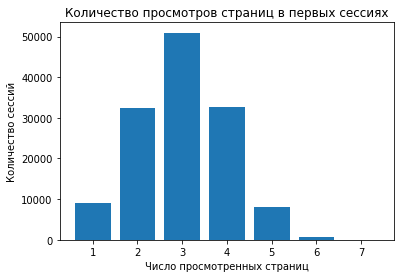

In [15]:
first_sessions = sessions_history[sessions_history['session_number'] == 1]

page_counts = (
    first_sessions
    .groupby('page_counter')
    .size()
    .reset_index(name='sessions_count')
)

plt.figure()
plt.bar(page_counts['page_counter'], page_counts['sessions_count'])
plt.title('Количество просмотров страниц в первых сессиях')
plt.xlabel('Число просмотренных страниц')
plt.ylabel('Количество сессий')
plt.show()

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. 

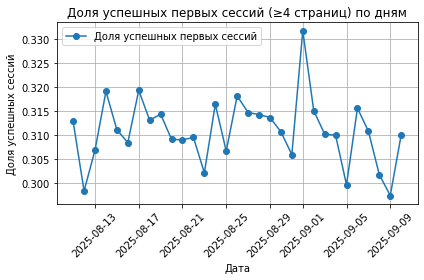

In [16]:
sessions_history['good_session'] = (sessions_history['page_counter'] >= 4).astype(int)

first_sessions = sessions_history[sessions_history['session_number'] == 1].copy()
first_sessions['session_date'] = pd.to_datetime(first_sessions['session_date'])

daily_good_share = (
    first_sessions
    .groupby('session_date')['good_session']
    .mean()
    .reset_index()
    .sort_values('session_date')
)

plt.figure()
plt.plot(daily_good_share['session_date'], daily_good_share['good_session'], marker='o', label='Доля успешных первых сессий')
plt.title('Доля успешных первых сессий (≥4 страниц) по дням')
plt.xlabel('Дата')
plt.ylabel('Доля успешных сессий')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2. Подготовка к тесту

#### 2.1. Расчёт размера выборки

Параметры для расчета выбрки:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. 

In [17]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
# Задайте параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода
power = 1 - beta  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = p * 0.03  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")
print(f"Количество пользователей задействованных в эксперименте: {int(sample_size)*2}")

Необходимый размер выборки для каждой группы: 41040
Количество пользователей задействованных в эксперименте: 82080


#### 2.2. Расчёт длительности A/B-теста

In [18]:
from math import ceil

# Среднее количество уникальных пользователей приложения в день по историческим данным
avg_daily_users = sessions_history.groupby('session_date')['user_id'].nunique().mean()

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size * 2 / avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровне трафика в {int(avg_daily_users)} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровне трафика в 9907 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

Для расчёта процентной разницы воспользуйемся формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

Процентная разница между группами A и B: 0.74%


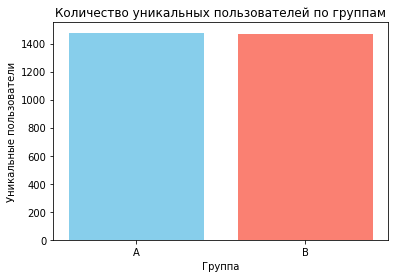

In [19]:
sessions_test_part = pd.read_csv('/datasets/sessions_project_test_part.csv')

group_counts = sessions_test_part.groupby('test_group')['user_id'].nunique().reset_index()
group_counts.columns = ['Группа', 'Уникальные пользователи']

a_users = group_counts.loc[group_counts['Группа'] == 'A', 'Уникальные пользователи'].values[0]
b_users = group_counts.loc[group_counts['Группа'] == 'B', 'Уникальные пользователи'].values[0]

percent_diff = 100 * abs(a_users - b_users) / a_users
print(f"Процентная разница между группами A и B: {percent_diff:.2f}%")

plt.figure()
plt.bar(group_counts['Группа'], group_counts['Уникальные пользователи'], color=['skyblue', 'salmon'])
plt.title('Количество уникальных пользователей по группам')
plt.xlabel('Группа')
plt.ylabel('Уникальные пользователи')
plt.show()

Группы равны

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, нужно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

In [20]:
users_a = set(sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'])
users_b = set(sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'])

overlap_users = users_a.intersection(users_b)
len(overlap_users)

0

#### 3.3. Равномерность разделения пользователей по устройствам
Нужно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

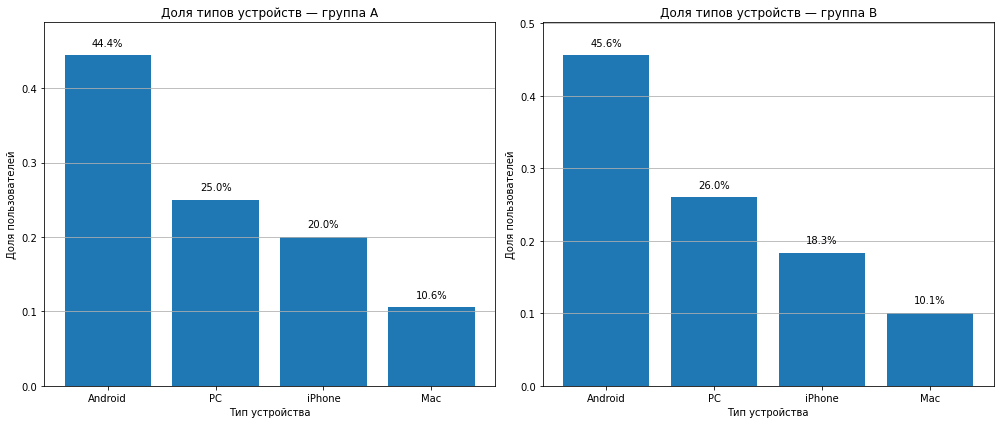

In [21]:
users_device = (
    sessions_test_part
    .groupby(['test_group', 'device'])['user_id']
    .nunique()
    .reset_index(name='users')
)

users_device['group_total'] = users_device.groupby('test_group')['users'].transform('sum')
users_device['share'] = users_device['users'] / users_device['group_total']

pivot = users_device.pivot(index='device', columns='test_group', values='share').fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, group in zip(axes, ['A', 'B']):
    if group in pivot.columns:
        data = pivot[group].sort_values(ascending=False)
    else:
        data = pd.Series(dtype=float)
    ax.bar(data.index, data.values)
    ax.set_title(f'Доля типов устройств — группа {group}')
    ax.set_xlabel('Тип устройства')
    ax.set_ylabel('Доля пользователей')
    ax.grid(axis='y')
    ax.set_ylim(0, max(0.1, data.max() * 1.1) if len(data) > 0 else 1)
    for i, v in enumerate(data.values):
        ax.text(i, v + 0.01, f'{v:.1%}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедимся, что пользователи равномерно распределены по регионам.

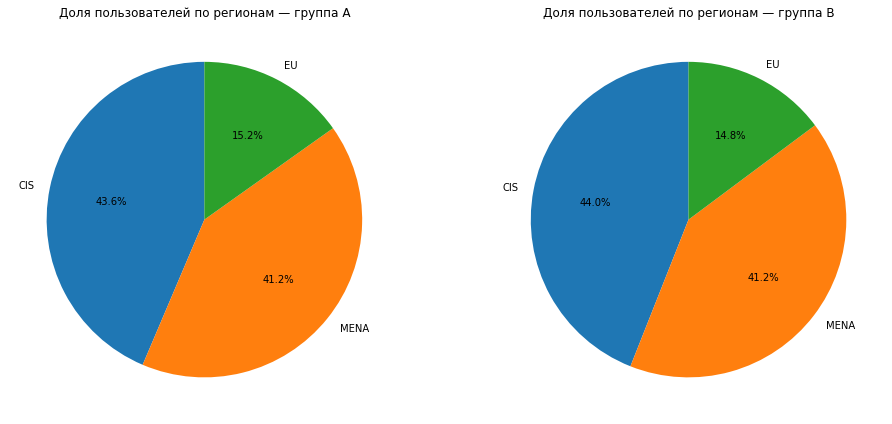

In [22]:
users_region = (
    sessions_test_part
    .groupby(['test_group', 'region'])['user_id']
    .nunique()
    .reset_index(name='users')
)

users_region['group_total'] = users_region.groupby('test_group')['users'].transform('sum')
users_region['share'] = users_region['users'] / users_region['group_total']

pivot_region = users_region.pivot(index='region', columns='test_group', values='share').fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, group in zip(axes, ['A', 'B']):
    if group in pivot_region.columns:
        data = pivot_region[group].sort_values(ascending=False)
    else:
        data = pd.Series(dtype=float)
    ax.pie(data.values, labels=data.index, autopct='%1.1f%%', startangle=90)
    ax.set_title(f'Доля пользователей по регионам — группа {group}')

plt.tight_layout()
plt.show()

#### 3.5. Вывод после проверки A/B-теста

- Процентная разница в количестве пользователей в группах равна 0,74%, можно считать, что существенного различия нет
- Выборки являются независимыми, пересечений выборок нет
- Равномерное распределение сохраняется и по типам устройств, и по регионам

Можно сделать вывод о корректном прохождении A/B-теста.

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считайте и сохраните в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [23]:
sessions_test = pd.read_csv('/datasets/sessions_project_test.csv')

sessions_test['good_session'] = (sessions_test['page_counter'] >= 4).astype(int)

#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик

Метрика - доля успешных сессий, где пользователь просмотрел 4 и более страниц (по полю `good_session`)

Нулевая гипотеза (Н0) - Новый алгоритм рекомендаций не изменяет долю успешных сессий по сравнению с текущим алгоритмом (средняя доля good_session в группе A равна среднему значению в группе B)

Альтернативная гипотеза (Н1) - Новый алгоритм рекомендаций увеличивает долю успешных сессий по сравнению с текущим алгоритмом (средняя доля good_session в группе B выше, чем в группе A)

Прокси-метрики: 
- Доля платных пользователей
- Среднее количество просмотренных страниц

Барьерные метрики:
- Метрики стабильности продукта (скорость загрузки, жалобы пользователей на контент)

#### 4.3. Сравнение доли успешных сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

In [24]:
first_sessions_test = sessions_test[sessions_test['session_number'] == 1].copy()

success_share = (
    first_sessions_test
    .groupby('test_group')['good_session']
    .mean()
    .reset_index()
)
success_share.columns = ['Группа', 'Доля успешных первых сессий']

share_diff = success_share.loc[success_share['Группа'] == 'B', 'Доля успешных первых сессий'].values[0] - \
             success_share.loc[success_share['Группа'] == 'A', 'Доля успешных первых сессий'].values[0]

print(success_share)
print(f"Разница в доле успешных первых сессий (B - A): {share_diff:.4f}")

  Группа  Доля успешных первых сессий
0      A                     0.315724
1      B                     0.314673
Разница в доле успешных первых сессий (B - A): -0.0011


#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге мы убедились, что количество успешных сессий в тестовой выборке примерно на 1.1% выше, чем в контрольной, но делать выводы только на основе этого значения будет некорректно. Для принятия решения необходимо ответить на вопрос: является ли это изменение статистически значимым.

In [25]:
from statsmodels.stats.proportion import proportions_ztest

agg = (first_sessions_test.groupby('test_group')['good_session'].agg(['sum', 'count']))
success_counts = [agg.loc['B', 'sum'], agg.loc['A', 'sum']]
nobs = [agg.loc['B', 'count'], agg.loc['A', 'count']]

stat, p_value = proportions_ztest(count=success_counts, nobs=nobs, alternative='larger')

print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Изменение доли успешных сессий статистически значимо")
else:
    print("Изменение доли успешных сессий не является статистически значимым")

p-value: 0.5784
Изменение доли успешных сессий не является статистически значимым


#### Вывод по результатам A/B-эксперимента

- В ходе эксперимента было задействовано 82080 пользователя на протяжении 9 дней
- Внедрение нового алгоритма повысило ключевую метрику на 1,1%
- p-value получилось равным 0,5784
- Данное изменение метрики нельзя считать статистически значимым, что говорит об отсутствии значимости нововведения